In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import sys
from utils import get_data_path
import plotly.graph_objects as go

notebook_dir = os.path.dirname(os.getcwd())  
project_root = os.path.dirname(notebook_dir) 
sys.path.append(project_root) 

In [2]:
df = pd.read_csv(get_data_path('data/data_raw.csv'))
df['StartDateTime'] = pd.to_datetime(df['StartDateTime'], format='%d/%m/%Y %H:%M')
df.set_index('StartDateTime', inplace=True)

print("Minimum value in 'ISEM DA Price':", df['ISEM DA Price'].min())
print("Number of zero or negative values:", (df['ISEM DA Price'] <= 0).sum())

# Ensure all values are strictly positive for multiplicative models
min_value = df['ISEM DA Price'].min()
if min_value <= 0:
    df['ISEM DA Price'] += abs(min_value) + 1e-6  # Shift all values upwards

# Check for NaNs and infinite values and fix the freuqncey for the model (used later)
df = df.asfreq('30min')
print("Number of NaNs in data:", df['ISEM DA Price'].isna().sum())
print("Number of infinite values in data:", np.isinf(df['ISEM DA Price']).sum())
print("Total number of data points:", len(df))
print("Number of values above 400:", (df['ISEM DA Price'] > 400).sum())
percentage_above_400 = (df['ISEM DA Price'] > 400).mean() * 100
print(f"Percentage of values above 400: {percentage_above_400:.2f}%")

df = df[np.isfinite(df['ISEM DA Price'])]

def smape(actual, forecast):
    return 100/len(actual) * np.sum(2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast)))



Minimum value in 'ISEM DA Price': -26.511
Number of zero or negative values: 496
Number of NaNs in data: 0
Number of infinite values in data: 0
Total number of data points: 52560
Number of values above 400: 660
Percentage of values above 400: 1.26%


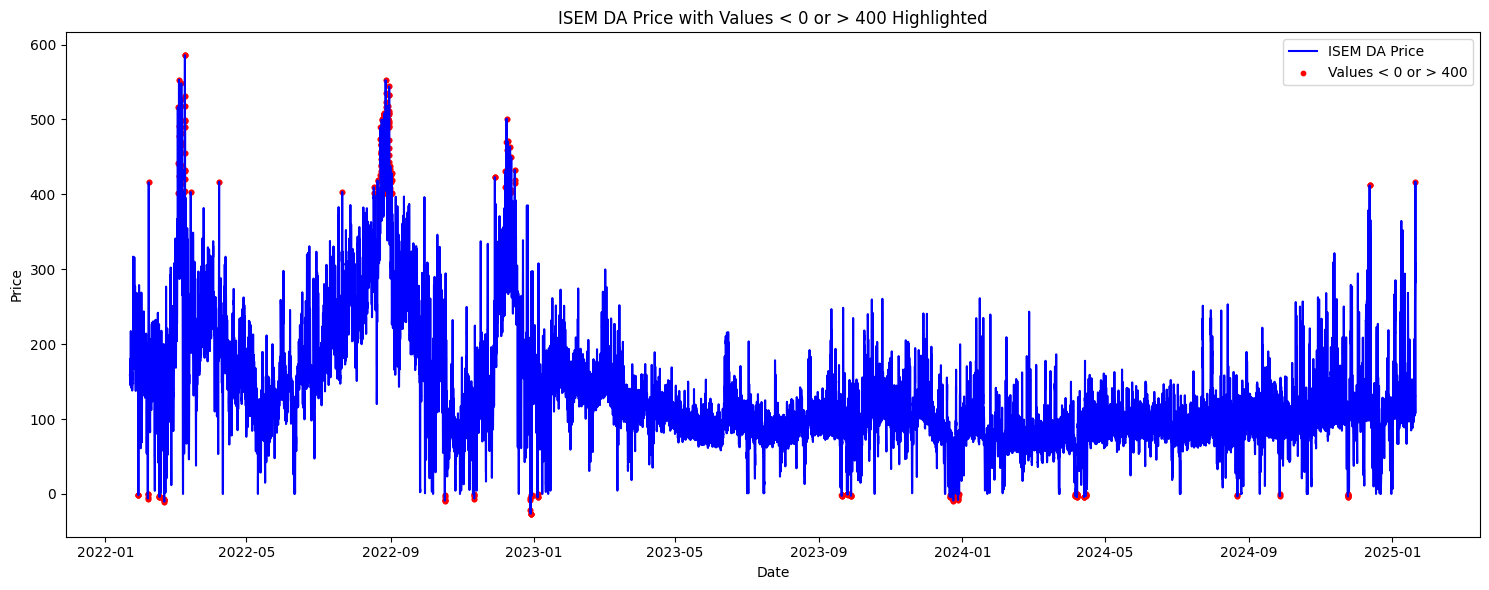

In [3]:
# Load the original unmodified data
raw_df = pd.read_csv(get_data_path('data/data_raw.csv'))
raw_df['StartDateTime'] = pd.to_datetime(raw_df['StartDateTime'], format='%d/%m/%Y %H:%M')
raw_df.set_index('StartDateTime', inplace=True)

plt.figure(figsize=(15, 6))

# Plot the full time series as a blue line
plt.plot(raw_df.index, raw_df['ISEM DA Price'], color='blue', label='ISEM DA Price')

# Highlight values below 0 or above 400 in red
highlight = (raw_df['ISEM DA Price'] < 0) | (raw_df['ISEM DA Price'] > 400)
plt.scatter(raw_df.index[highlight], raw_df['ISEM DA Price'][highlight],
            color='red', s=10, label='Values < 0 or > 400')

plt.title('ISEM DA Price with Values < 0 or > 400 Highlighted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


### configuration and training

#### Overview
Training: full data split into 80% training and 20% testing segments.
and evulates multiple model configurations for holt-winters ES to select the best forecasting approach.

#### how the code works:
- sMAPE Function: calcs symmetric MAEPE 
- data split: desciberd above
- Model configs: Define the  setups with varying trend types, seasonal components, seasonal periods, and damped trend.
- Model training & evals. Described below

#### Model training & evals:
- does this by training each config on historical price data.
- Forecasts for the test period.
- Computes RMSE, MAE, and sMAPE to assess model performance.
- Best Model Selection: Identifies the optimal configuration based on the lowest RMSE.

#### Config adjusting:
- Adjust configs: do this by adding lines in the configs list with ur parameters (trend, seasonal, seasonal_periods, damped_trend, and a descriptive name). experiment!

In [4]:
# using sMAPE function
def smape(actual, forecast):
    return 100/len(actual) * np.sum(2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast)))

# Keep only the last 4 months of data
cutoff_date = df.index[-1] - pd.DateOffset(months=12)
df_recent = df[df.index >= cutoff_date]  # Only keep data from the last 4 months

# Apply an 80/20 split to the reduced dataset
train_size = int(len(df_recent) * 0.6)
train = df_recent.iloc[:train_size]
test = df_recent.iloc[train_size:]

# Print details
print(f"New Training Period: {train.index.min()} to {train.index.max()}")
print(f"New Training Size: {len(train)}")
print(f"New Testing Period: {test.index.min()} to {test.index.max()}")
print(f"New Testing Size: {len(test)}")


# Model configurations
configs = [
    {"trend": None, "seasonal": "add", "seasonal_periods": 48, "damped_trend": False, 
     "name": "Daily Additive (Optimized)", "remove_bias": True, "smoothing_seasonal": 0.2},
    
    {"trend": None, "seasonal": "mul", "seasonal_periods": 48, "damped_trend": False, 
     "name": "Daily Multiplicative (Optimized)", "use_boxcox": True, "remove_bias": True, "smoothing_seasonal": 0.1},
    
    {"trend": None, "seasonal": "add", "seasonal_periods": 48, "damped_trend": False, 
     "name": "Daily Additive (Higher Smoothing)", "use_boxcox": True, "remove_bias": True, "smoothing_seasonal": 0.3},
    
    {"trend": None, "seasonal": "add", "seasonal_periods": 48, "damped_trend": False, 
     "name": "Daily Additive (Lower Smoothing)", "use_boxcox": True, "remove_bias": True, "smoothing_seasonal": 0.1},

    {"trend": "add", "seasonal": "add", "seasonal_periods": 48, "damped_trend": True, 
     "name": "Add-Trend + Add-Season (Damped)", "smoothing_seasonal": 0.2},
    
    {"trend": "add", "seasonal": "mul", "seasonal_periods": 48, "damped_trend": True, 
     "name": "Add-Trend + Mul-Season (Damped)", "smoothing_seasonal": 0.2},
    
    {"trend": "add", "seasonal": "add", "seasonal_periods": 96, "damped_trend": True, 
     "name": "2-Day Seasonality", "smoothing_seasonal": 0.2},
    
    {"trend": None, "seasonal": "mul", "seasonal_periods": 336, "damped_trend": False, 
     "name": "Weekly Multiplicative", "smoothing_seasonal": 0.1}
]

# Train and evaluate models
print("Testing Holt-Winters configurations:")
results = []

try:
    for config in configs:
        try:
            # Skip if not enough data
            if config["seasonal_periods"] > len(train) / 2:
                print(f"Skipping {config['name']} - insufficient data")
                continue
            
            print(f"Fitting {config['name']}...")
            
            model = ExponentialSmoothing(
    train['ISEM DA Price'],
    trend=config["trend"],
    seasonal=config["seasonal"],
    seasonal_periods=config["seasonal_periods"],
    damped_trend=config["damped_trend"],
    initialization_method="estimated"
).fit(
    optimized=True,
    smoothing_seasonal=config["smoothing_seasonal"]
)




            # Standard Holt-Winters forecast
            hw_preds = model.forecast(len(test))

            # Smooth predictions using rolling mean
            rolling_preds = hw_preds.rolling(window=3, center=True).mean()

            # Weighted combination of standard and smoothed forecast
            final_preds = (0.7 * hw_preds) + (0.3 * rolling_preds)
            final_preds.fillna(hw_preds, inplace=True)  # Handle NaN values

            # Evaluate model
            mae = mean_absolute_error(test['ISEM DA Price'], final_preds)
            print(f"Final Optimized MAE: {mae:.2f}")

            
            # create forecasts
            preds = model.forecast(len(test))
            preds = pd.Series(preds, index=test.index)

            
            # calc metrics
            rmse = np.sqrt(mean_squared_error(test['ISEM DA Price'], preds))
            mae = mean_absolute_error(test['ISEM DA Price'], preds)
            smape_val = smape(test['ISEM DA Price'], preds)
            
            # store results
            results.append({
                "name": config["name"],
                "model": model, 
                "predictions": preds,
                "rmse": rmse,
                "mae": mae,
                "smape": smape_val
            })
            
            print(f"{config['name']}: RMSE={rmse:.2f}, MAE={mae:.2f}, sMAPE={smape_val:.2f}%")
            
        except Exception as e:
            print(f"Error with {config['name']}: {str(e)}")
    
    # Find best model
    if not results:
        print("No successful models.")
        best_model_info = None
    else:
        best_model_info = min(results, key=lambda x: x["rmse"])
        print(f"\nBest model: {best_model_info['name']} (RMSE: {best_model_info['rmse']:.2f})")
        
except Exception as e:
    print(f"Error in modeling process: {str(e)}")
    import traceback
    traceback.print_exc()
    best_model_info = None

New Training Period: 2024-01-20 23:30:00 to 2024-08-27 13:30:00
New Training Size: 10541
New Testing Period: 2024-08-27 14:00:00 to 2025-01-20 23:30:00
New Testing Size: 7028
Testing Holt-Winters configurations:
Fitting Daily Additive (Optimized)...
Final Optimized MAE: 34.20
Daily Additive (Optimized): RMSE=52.37, MAE=34.25, sMAPE=24.62%
Fitting Daily Multiplicative (Optimized)...
Final Optimized MAE: 34.91
Daily Multiplicative (Optimized): RMSE=53.24, MAE=35.04, sMAPE=24.93%
Fitting Daily Additive (Higher Smoothing)...
Final Optimized MAE: 35.03
Daily Additive (Higher Smoothing): RMSE=52.11, MAE=35.10, sMAPE=25.05%
Fitting Daily Additive (Lower Smoothing)...
Final Optimized MAE: 34.32
Daily Additive (Lower Smoothing): RMSE=53.84, MAE=34.35, sMAPE=24.49%
Fitting Add-Trend + Add-Season (Damped)...
Final Optimized MAE: 34.66
Add-Trend + Add-Season (Damped): RMSE=52.41, MAE=34.72, sMAPE=25.32%
Fitting Add-Trend + Mul-Season (Damped)...
Final Optimized MAE: 37.82
Add-Trend + Mul-Season (D

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [5]:
# Find the 'Daily Additive (Lower Smoothing)' model in the results list
lower_smoothing_model = next(
    (model for model in results if model["name"] == "Daily Additive (Lower Smoothing)"), None
)

if lower_smoothing_model:
    best_preds = lower_smoothing_model["predictions"]
    model_name = lower_smoothing_model["name"]

    actual = test['ISEM DA Price']
    predicted = lower_smoothing_model['predictions']

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    smape_val = smape(actual, predicted)
    r2 = r2_score(actual, predicted)


    # Create plot
    fig = go.Figure()
    
    # Add all training data
    fig.add_trace(go.Scatter(
        x=train.index, 
        y=train['ISEM DA Price'],
        name='Training Data',
        line=dict(color='blue')
    ))
    
    # Add all test data (actual values)
    fig.add_trace(go.Scatter(
        x=test.index, 
        y=test['ISEM DA Price'],
        name='Actual Values',
        line=dict(color='green')
    ))
    
    # Add forecast from lower smoothing model
    fig.add_trace(go.Scatter(
        x=test.index, 
        y=best_preds,
        name='Forecast (Lower Smoothing)',
        line=dict(color='red')
    ))
    
    # Layout
    fig.update_layout(
        title=f'Holt-Winters: {model_name}',
        xaxis_title='Date',
        yaxis_title='Price (€/MWh)',
        hovermode='x unified',
        legend=dict(orientation="h", y=1.1)
    )
    
    # Range selector for navigation
    fig.update_xaxes(
        rangeslider_visible=True,
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        )
    )
    
    # Show the plot
    fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### plotting 

to teammates: the code is written so that ideally you shouldnt have to touch this box 

### Other Analysis

#### PLOT 1: Residuals Over Time
- Calculation: The difference between actual and predicted prices for each point in the test set. 
- Insight: Shows howe prediction errors change over time. Large spikes suggest the model struggles, especially in winter time

#### PLOT 2: MAE by Hour of Day
- Calculation: Find the average absolute error for each hour of the day (0-23).  
- Insight: thjer are patterns in errors across the day, modul performs better at night (0-6) and worse during peak hours (11-17).

#### PLOT 3: MAE by Price Range
- Calculation: Find the average absolute error for different price ranges (0-50, 50-100, 100-150, >150 €/ mega watt hour)  
- Insight: Shows that the model struggles with very low or very high prices but does well in the middle range. IMO we can fix this by just training on 1 year's worth of data. 


USING: Daily Additive (Lower Smoothing)
Configuration: Daily Additive (Lower Smoothing)
RMSE: 53.84
MAE: 34.35
sMAPE: 24.49%


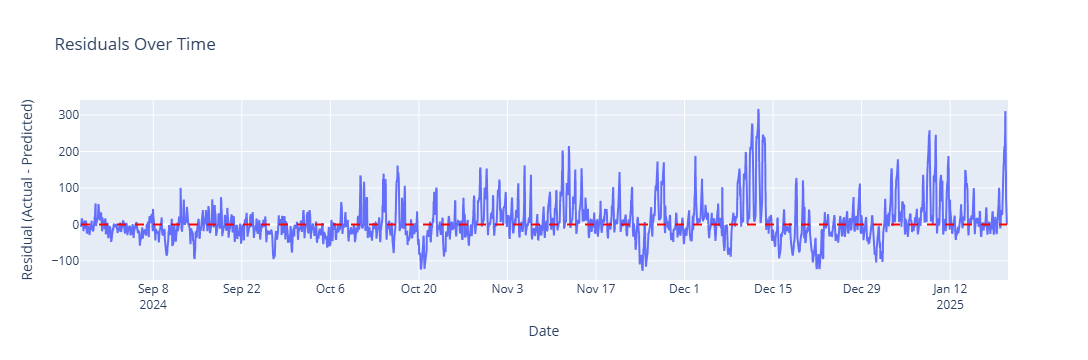

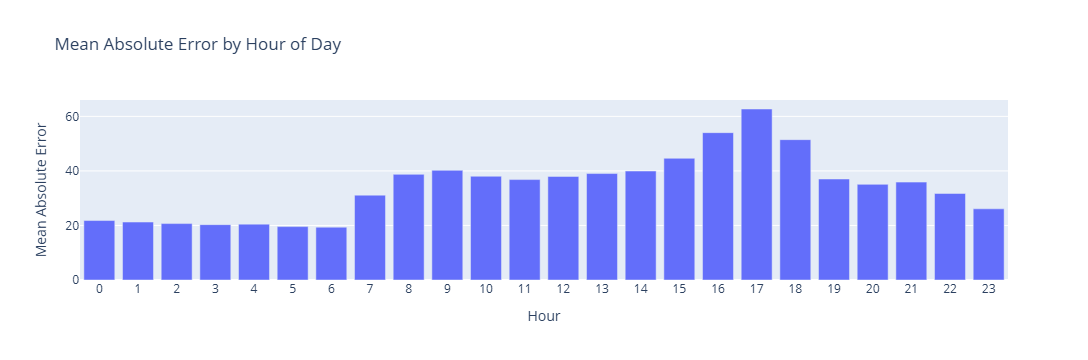

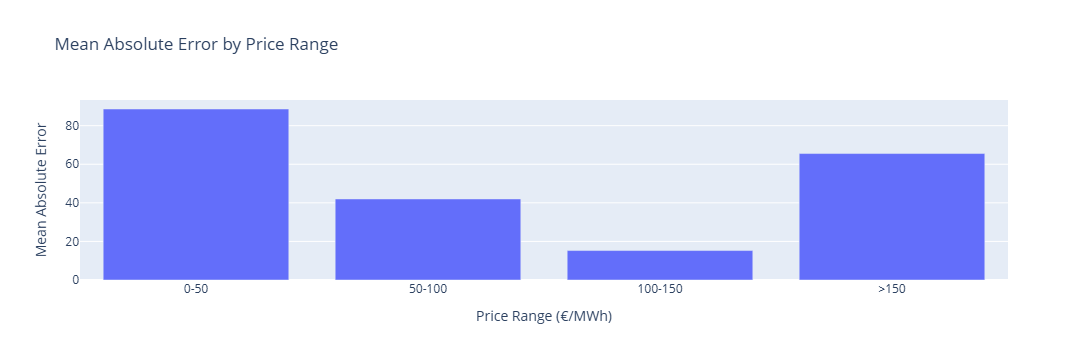

In [43]:
# Select the lower smoothing model instead of the best RMSE one
lower_smoothing_model = next(
    (model for model in results if model["name"] == "Daily Additive (Lower Smoothing)"), None
)

if lower_smoothing_model:
    print("\nUSING: Daily Additive (Lower Smoothing)")
    print(f"Configuration: {lower_smoothing_model['name']}")
    print(f"RMSE: {lower_smoothing_model['rmse']:.2f}")
    print(f"MAE: {lower_smoothing_model['mae']:.2f}")
    print(f"sMAPE: {lower_smoothing_model['smape']:.2f}%")

    best_preds = lower_smoothing_model["predictions"]
    residuals = test['ISEM DA Price'] - best_preds

    # Prepare data for analysis
    test_copy = test.copy()
    test_copy['hour'] = test_copy.index.hour
    test_copy['abs_residual'] = abs(residuals)
    test_copy['price_range'] = pd.cut(test_copy['ISEM DA Price'], 
                                    bins=[0, 50, 100, 150, float('inf')],
                                    labels=['0-50', '50-100', '100-150', '>150'])

    # 1. Residuals plot
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=test.index, y=residuals, name='Residuals'))
    fig.add_shape(type="line", x0=test.index[0], y0=0, x1=test.index[-1], y1=0, 
                 line=dict(color="red", width=2, dash="dash"))
    fig.update_layout(title='Residuals Over Time', xaxis_title='Date', 
                     yaxis_title='Residual (Actual - Predicted)')
    fig.show()

    # 2. Error by hour
    hourly_error = test_copy.groupby('hour', observed=True)['abs_residual'].mean()
    fig = go.Figure(data=[go.Bar(x=hourly_error.index, y=hourly_error.values)])
    fig.update_layout(title='Mean Absolute Error by Hour of Day', 
                     xaxis_title='Hour', yaxis_title='Mean Absolute Error',
                     xaxis=dict(tickmode='linear', tick0=0, dtick=1))
    fig.show()

    # 3. Error by price range
    price_range_error = test_copy.groupby('price_range', observed=True)['abs_residual'].mean()
    fig = go.Figure(data=[go.Bar(x=price_range_error.index, y=price_range_error.values)])
    fig.update_layout(title='Mean Absolute Error by Price Range',
                     xaxis_title='Price Range (€/MWh)', yaxis_title='Mean Absolute Error')
    fig.show()



Generating next 24-hour forecast using Daily Additive (Lower Smoothing)...


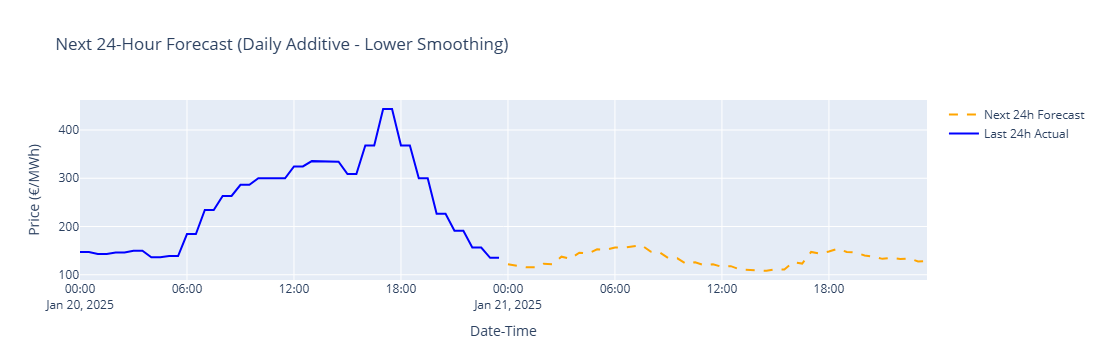


Future Predictions Check:
2025-01-21 00:00:00    121.962623
2025-01-21 00:30:00    118.913998
2025-01-21 01:00:00    115.677464
2025-01-21 01:30:00    115.432680
2025-01-21 02:00:00    122.950208
2025-01-21 02:30:00    121.985232
2025-01-21 03:00:00    137.469852
2025-01-21 03:30:00    132.985588
2025-01-21 04:00:00    145.825227
2025-01-21 04:30:00    144.300276
2025-01-21 05:00:00    152.714875
2025-01-21 05:30:00    151.757512
2025-01-21 06:00:00    156.396092
2025-01-21 06:30:00    156.365763
2025-01-21 07:00:00    158.500075
2025-01-21 07:30:00    161.340370
2025-01-21 08:00:00    147.932799
2025-01-21 08:30:00    146.371711
2025-01-21 09:00:00    134.590105
2025-01-21 09:30:00    134.105651
2025-01-21 10:00:00    122.728633
2025-01-21 10:30:00    125.976839
2025-01-21 11:00:00    119.920046
2025-01-21 11:30:00    121.891515
2025-01-21 12:00:00    116.369672
2025-01-21 12:30:00    117.842334
2025-01-21 13:00:00    111.220084
2025-01-21 13:30:00    110.185747
2025-01-21 14:00:00  

In [44]:
# Get the 'Daily Additive (Lower Smoothing)' model
lower_smoothing_model = next(
    (model for model in results if model["name"] == "Daily Additive (Lower Smoothing)"), None
)

if lower_smoothing_model:
    print("\nGenerating next 24-hour forecast using Daily Additive (Lower Smoothing)...")

    # Generate forecast for the next 24 hours (48 half-hour steps)
    future_steps = 48
    future_preds = lower_smoothing_model["model"].forecast(future_steps)

    last_timestamp = test.index[-1]

    # Create a new datetime index for forecasted values
    future_index = pd.date_range(start=last_timestamp, periods=future_steps + 1, freq='30min')[1:]

    # Convert to Pandas Series and align index
    future_preds = pd.Series(future_preds.values, index=future_index)

    # ---- Plot for Next 24-Hour Forecast ----
    fig_future = go.Figure()

    # Add forecast line (orange dashed)
    fig_future.add_trace(go.Scatter(
        x=future_preds.index, 
        y=future_preds.values,  
        name='Next 24h Forecast',
        line=dict(color='orange', dash='dash')
    ))

    # Add actual last 24 hours of test data (blue solid)
    fig_future.add_trace(go.Scatter(
        x=test.index[-48:],  
        y=test['ISEM DA Price'].iloc[-48:],
        name='Last 24h Actual',
        line=dict(color='blue')
    ))

    # Layout
    fig_future.update_layout(
        title='Next 24-Hour Forecast (Daily Additive - Lower Smoothing)',
        xaxis_title='Date-Time',
        yaxis_title='Price (€/MWh)',
        hovermode='x unified'
    )

    # Show the plot
    fig_future.show()

    # Output and save forecast
    print("\nFuture Predictions Check:")
    print(future_preds)

    future_preds.to_csv("forecast_next_24h.csv", header=["ISEM DA Price"])
    print("Forecast saved as 'forecast_next_24h.csv'")
